In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn

import os, random


def reset_random_seeds():
    os.environ['PYTHONHASHSEED']=str(2)
    torch.manual_seed(2)
    np.random.seed(2)
    random.seed(2)
    torch.cuda.manual_seed(2)
    torch.cuda.manual_seed_all(2)
    
reset_random_seeds() 

df_train = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/train.csv")
df_test = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/test.csv")

split = len(df_train)

df = pd.concat([df_train,df_test])
input_col = 'text'
output_col = "label-fine"

X = df[input_col].tolist()
Y = df[output_col].tolist()

xtrain,xtest = X[:split],X[split:]
ytrain,ytest = Y[:split],Y[split:]

In [2]:
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, TensorDataset

name = "google/electra-small-discriminator"

tokenizer = AutoTokenizer.from_pretrained(name)

BATCH = 8

def create_batch_data(x,y,shuffle=True,batch=32):
    x_ = tokenizer(x, return_tensors="pt",max_length=256,truncation=True,padding=True)
    y_ = torch.tensor(y)
    dataset = TensorDataset(x_["input_ids"], x_["attention_mask"], y_)
    data = DataLoader(dataset, batch_size=batch, shuffle=shuffle)
    return data

train = create_batch_data(xtrain,ytrain,batch=BATCH)
test = create_batch_data(xtest,ytest,shuffle=False,batch=BATCH * 2)

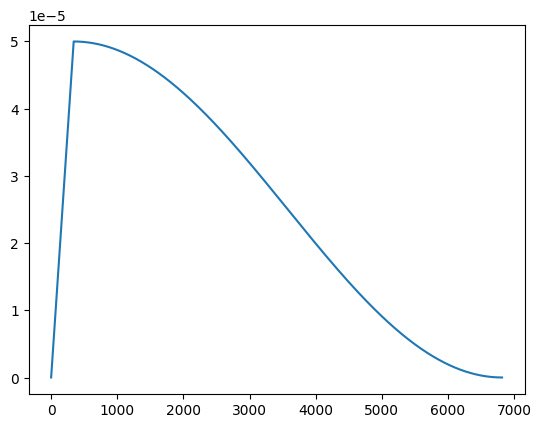

In [3]:
from cosine_lr_scheduler import CosineLRScheduler
import matplotlib.pyplot as plt

PEAK_LR = 5e-5
END_LR = 1e-8
INIT_LR = 1e-8
WARMUP_RATE = 0.05
EPOCHS = 10
TOTAL_STEPS = len(train) * EPOCHS

lr_scheduler = CosineLRScheduler(TOTAL_STEPS,peak_lr=PEAK_LR,min_lr=END_LR,
                                 init_lr=INIT_LR,warmup_rate=WARMUP_RATE)

plt.plot([lr_scheduler(i) for i in range(1,TOTAL_STEPS+1)])

In [4]:
class GeometricPooling(nn.Module):
    
    def __init__(self,temp=1):
        super().__init__()
        self.score = None
        self.temp = temp
    
    def forward(self,x,mask):
        mean_vec = (x * mask[:,:,torch.newaxis]).sum(1)
        mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
        mean_vec = mean_vec[:,torch.newaxis,:]
        mean_vec = mean_vec.transpose(1,2)
        score = torch.matmul(x,mean_vec).squeeze(-1)
        score = torch.where(mask == 0,-1e8,score)
        score = torch.softmax(score,dim=-1).unsqueeze(-1)
        self.score = score
        return torch.sum(x * score,dim=1)
    
    
class AttentionPool(nn.Module):
    
    def __init__(self,dim=256,temp=1):
        super().__init__()
        self.dim = dim 
        self.score = None
        self.w = nn.Linear(dim,1,bias=False)
        self.temp = temp
        
    def forward(self,x,mask=None):
        attn = self.w(x)
        if mask is not None:
            mask = mask[:,:,torch.newaxis]
            attn = torch.where(mask == 0,-1e8,attn)
        attn = torch.softmax(attn/self.temp,axis=1)
        self.score = attn
        x = x * attn
        return x.sum(1)
    
    

In [5]:
from torchinfo import summary


class Classifier(nn.Module):
    
    def __init__(self,dim=256,n_classes=1,pool_type=None):
        super().__init__()
        self.electra = AutoModel.from_pretrained("google/electra-small-discriminator")
        self.cls_head = nn.Linear(dim,n_classes)
        self.pool_type = pool_type
        self.pooling = nn.ModuleDict({"attn_pool":AttentionPool(dim),
                                      "geometric_pool":GeometricPooling()})
        
    def forward(self,x,return_pool=False,return_final_seq=False):
        ids,mask = x
        x = self.electra(input_ids=ids,attention_mask=mask)
        x = x['last_hidden_state']
        
        if return_final_seq:
            return x
        
        x = self.pooling[self.pool_type](x,mask=mask)
        if return_pool:
            return x
        x = self.cls_head(x)
        return x
    

reset_random_seeds()

n_classes = len(np.unique(Y))
model = Classifier(n_classes=1)
print(summary(model))
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

Layer (type:depth-idx)                                       Param #
Classifier                                                   --
├─ElectraModel: 1-1                                          --
│    └─ElectraEmbeddings: 2-1                                --
│    │    └─Embedding: 3-1                                   3,906,816
│    │    └─Embedding: 3-2                                   65,536
│    │    └─Embedding: 3-3                                   256
│    │    └─LayerNorm: 3-4                                   256
│    │    └─Dropout: 3-5                                     --
│    └─Linear: 2-2                                           33,024
│    └─ElectraEncoder: 2-3                                   --
│    │    └─ModuleList: 3-6                                  9,477,120
├─Linear: 1-2                                                257
├─ModuleDict: 1-3                                            --
│    └─AttentionPool: 2-4                                    --
│    │    

In [6]:
from tqdm.auto import tqdm


def train_model(data,model,EPOCHS,file='saved_weights.pt'):

    global losses
    
    opt = torch.optim.AdamW(model.parameters(),weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()

    train,test = data

    losses = {'train':[],'valid':[]}
    
    step = 1

    for e in range(1,EPOCHS + 1):

        print(f"{e}/{EPOCHS}")
        print(f"Learning Rate = {lr_scheduler(step)}")

        loss = 0
        model.train()

        for i,batch in enumerate(tqdm(train),1):

            lr = lr_scheduler(step)
            opt.param_groups[0]['lr'] = lr

            opt.zero_grad()

            ids,mask,y = batch
            ids = ids.to(device)
            mask = mask.to(device)
            y = y.to(device)
            y = y.long()
            pred = model([ids,mask])
            batch_loss = loss_fn(pred,y)
            batch_loss.backward()
            opt.step()

            loss += batch_loss.item()
            
            step += 1

        loss = round(loss / len(train),4)
        losses['train'].append(loss)
        train_loss = loss

        model.eval()
        loss = 0

        with torch.no_grad():

            for i,batch in enumerate(tqdm(test)):

                ids,mask,y = batch
                ids = ids.to(device)
                mask = mask.to(device)
                y = y.to(device)
                y = y.long() 
                pred = model([ids,mask])
                batch_loss = loss_fn(pred,y)
                loss += batch_loss.item()
        
        print(f'Train Loss = {train_loss}')
        loss = round(loss / len(test),4)
        print(f"Val Loss = {loss}")


        if e == 1 or loss < min(losses['valid']):
            torch.save(model.state_dict(),file)
            print("--weights saved")

        losses['valid'].append(loss)
        print('--------------------------------------')
        print()

In [11]:
reset_random_seeds()

model = Classifier(n_classes=n_classes,pool_type='attn_pool')
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_model((train,test),model,EPOCHS=EPOCHS,file='attn_pool.pt')

1/10
Learning Rate = 1e-08


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 2.3185
Val Loss = 1.3358
--weights saved
--------------------------------------

2/10
Learning Rate = 4.965710302874277e-05


  0%|          | 0/682 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 0.0726
Val Loss = 0.559
--------------------------------------

10/10
Learning Rate = 1.3603655341837609e-06


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 0.0657
Val Loss = 0.5559
--weights saved
--------------------------------------



In [12]:
reset_random_seeds()

model = Classifier(n_classes=n_classes,pool_type='geometric_pool')
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_model((train,test),model,EPOCHS=EPOCHS,file='geometric_pool.pt')

1/10
Learning Rate = 1e-08


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 2.3691
Val Loss = 1.3722
--weights saved
--------------------------------------

2/10
Learning Rate = 4.965710302874277e-05


  0%|          | 0/682 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 0.0771
Val Loss = 0.5077
--weights saved
--------------------------------------

10/10
Learning Rate = 1.3603655341837609e-06


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 0.0718
Val Loss = 0.5071
--weights saved
--------------------------------------



In [7]:
def load_model(pool_type):
    model = Classifier(n_classes=n_classes,pool_type=pool_type)
    model = model.to('cuda')
    state_dict = torch.load(f'{pool_type}.pt', map_location='cuda')
    model.load_state_dict(state_dict)
    return model

model1 = load_model('attn_pool')
model2 = load_model('geometric_pool')

In [8]:
import matplotlib.pyplot as plt
import seaborn as sb


def get_weighted_probs(seq):
    inp = tokenizer(seq, return_tensors="pt",max_length=256,truncation=True,padding=True)
    seq,mask = inp['input_ids'],inp['attention_mask']
    seq = seq.to('cuda')
    mask = mask.to('cuda')
    p1 = model1([seq,mask])
    p2 = model2([seq,mask])

    attn_probs = model1.pooling['attn_pool'].score.detach().cpu().numpy().reshape(-1)
    geo_probs = model2.pooling['geometric_pool'].score.detach().cpu().numpy().reshape(-1)
    text = tokenizer.convert_ids_to_tokens(seq[0].tolist())

    attn_plot = {w:p for w,p in zip(text,attn_probs)}
    geo_plot = {w:p for w,p in zip(text,geo_probs)}
    
    print(' '.join([x for x in text]))
    
    fig,ax = plt.subplots(1,2,figsize=(12,8),sharey=True)

    sb.barplot(geo_plot,orient='h',ax=ax[0])
    sb.barplot(attn_plot,orient='h',ax=ax[1])

    ax[0].set_title('geometric_pool')
    ax[1].set_title('attn_pool')

    plt.tight_layout()
    
#     p1,p2 = torch.sigmoid(p1[0][0]),torch.sigmoid(p2[0][0])
    p1,p2 = torch.softmax(p1,dim=-1),torch.softmax(p2,dim=-1)
    i1,i2 = torch.argmax(p1),torch.argmax(p2)
    p1 = p1[0][i1]
    p2 = p2[0][i2]
    i1 = int(i1.detach().cpu().numpy())
    i2 = int(i2.detach().cpu().numpy())
    p1 = p1.detach().cpu().numpy()
    p2 = p2.detach().cpu().numpy()
    return (p1,i1) , (p2,i2)

[CLS] what state has the least amount of rain per year ? [SEP]
attn_pool : 11.0000 || geometric_pool : 11.0000


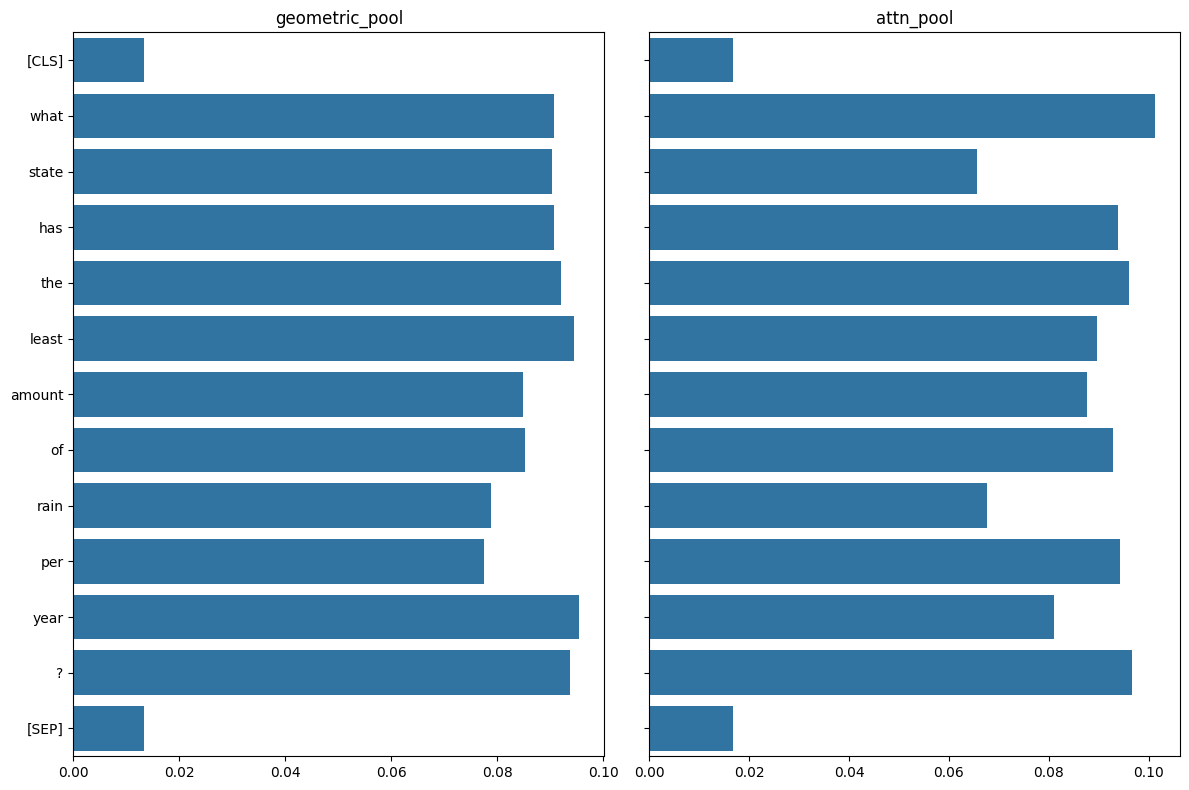

In [9]:
i = np.random.randint(0,len(xtest))
seq = xtest[i]

x1,x2 = get_weighted_probs(seq)
# print(p1,p2)
print(f"attn_pool : {x1[1]:.4f} || geometric_pool : {x2[1]:.4f}")

In [10]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
from tqdm import tqdm
import torch

def get_pooling_scores(seq):
    model1.eval()
    model2.eval()
    
    with torch.no_grad():
        model1(seq)
        model2(seq)

        # Shape: [batch_size, seq_len]
        attn_probs = model1.pooling['attn_pool'].score.cpu().numpy()[:,:,0]
        geo_probs = model2.pooling['geometric_pool'].score.cpu().numpy()[:,:,0]
        
        # Bring input seq to CPU to check for padding safely
        seq_np = seq[0].cpu().numpy()
        
    batch_attn = []
    batch_geo = []
    
    # Iterate through each sequence in the batch individually
    for i in range(seq_np.shape[0]):
        # Safer masking: Use the input tokens to find padding, assuming padding ID is 0
        idx = np.where(seq_np[i] > 0)
        
        # Append only the valid tokens for THIS specific sentence
        batch_attn.append(attn_probs[i][idx])
        batch_geo.append(geo_probs[i][idx])
        
    return batch_attn, batch_geo


# --- Test Loop ---
scores = {'attn': [], 'geo': []}

for x,mask, _ in test:
    # Move x to GPU if your test loop doesn't do it automatically
    # x = x.to('cuda')
    x = x.to('cuda')
    mask = mask.to('cuda')
    attn, geo = get_pooling_scores([x,mask])
    
    # Because attn and geo are now lists of arrays, .extend() correctly 
    # adds arrays (sequences) to the scores lists instead of individual floats
    scores['attn'].extend(attn)
    scores['geo'].extend(geo)


    
# --- Correlation Calculation ---
s_corr = 0
p_corr = 0
count = 0  # Must start at 0

for s1, s2 in tqdm(zip(scores['attn'], scores['geo']), total=len(scores['attn'])):
    # Spearman requires at least 2 data points (tokens) to rank
    if len(s1) > 1:
        sm = spearmanr(s1, s2).statistic
        ps = pearsonr(s1, s2).statistic
        # Ignore NaN values (happens if a sequence has perfectly uniform weights, causing 0 variance)
        if not np.isnan(sm) and not np.isnan(ps):
            s_corr += sm
            p_corr += ps
            count += 1

print(f"\nEvaluated {count} valid sequences.")
print(f"Average Spearman Correlation: {s_corr / count:.4f}")
print(f"Average Pearson Correlation: {p_corr / count:.4f}")

100%|███████████████████████████████████████| 500/500 [00:00<00:00, 1198.67it/s]


Evaluated 500 valid sequences.
Average Spearman Correlation: 0.6706
Average Pearson Correlation: 0.9282


In [12]:
vec_norms = []

model2.eval()

with torch.no_grad():

    for x,mask, _ in test:
        x = x.to('cuda')
        mask = mask.to('cuda')
        vec_seq = model2([x,mask],return_final_seq=True)
        norm = torch.norm(vec_seq,dim=-1)
        idx = torch.where(norm > 0)
        norm = norm[idx]
        norm = norm.detach().cpu().numpy()
        vec_norms.extend(norm)
        
vec_norms = np.array(vec_norms)
vec_norms.std()
    
    
    


np.float32(0.2190227)